# TP4 – RNN/CNN sur IMDB (GloVe)

Ce notebook suit les étapes du TP : prétraitement, embedding GloVe, puis classification avec un réseau dense, un CNN et un LSTM. Les sections finales ajoutent GRU et RNN+CNN pour le compte rendu.

In [ ]:
import tensorflow as tf
print(tf.__version__)

2.21.0


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import re
import random

from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, Flatten, Dense, Conv1D, MaxPooling1D, LSTM, GRU
from sklearn.model_selection import train_test_split

np.random.seed(42)
random.seed(42)
%matplotlib inline

## Importation du dataset
1. Importer IMDB avec `read_csv`.
2. Donner la dimension du dataset et verifier les valeurs NULL.
3. Afficher les 5 premieres lignes.
4. Utiliser `countplot` (seaborn) pour verifier l'equilibrage.
5. Afficher le 4eme review et commenter.

In [ ]:
dataset_path = r"IMDB Dataset\IMDB Dataset.csv"
movie_reviews = pd.read_csv(dataset_path)

print("Dimension:", movie_reviews.shape)
print("Valeurs NULL:")
print(movie_reviews.isnull().sum())
movie_reviews.head()

Dimension: (50000, 2)
Valeurs NULL:
review       0
sentiment    0
dtype: int64


,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive
3,Basically there's a family where a little boy ...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive


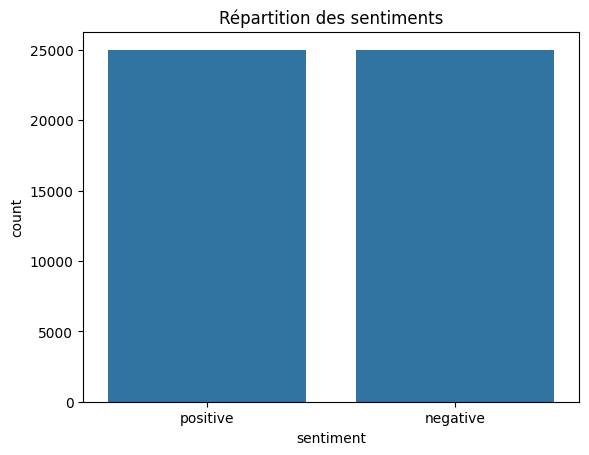

In [ ]:
sns.countplot(x="sentiment", data=movie_reviews)
plt.title("Répartition des sentiments")
plt.show()

In [ ]:
movie_reviews['review'].iloc[3]

"Basically there's a family where a little boy (Jake) thinks there's a zombie in his closet & his parents are fighting all the time.<br /><br />This movie is slower than a soap opera... and suddenly, Jake decides to become Rambo and kill the zombie.<br /><br />OK, first of all when you're going to make a film you must Decide if its a thriller or a drama! As a drama the movie is watchable. Parents are divorcing & arguing like in real life. And then we have Jake with his closet which totally ruins all the film! I expected to see a BOOGEYMAN similar movie, and instead i watched a drama with some meaningless thriller spots.<br /><br />3 out of 10 just for the well playing parents & descent dialogs. As for the shots with Jake: just ignore them."

## Prétraitement
1. Executer le code et l'expliquer.
2. Pretraiter les reviews et les stocker dans une nouvelle liste.
3. Reafficher le 4eme review et commenter.

Le code ci-dessous supprime les balises HTML, la ponctuation et les chiffres, retire les caracteres isoles et normalise les espaces.

In [ ]:
TAG_RE = re.compile(r'<[^>]+>')

def remove_tags(text):
    return TAG_RE.sub('', text)

def preprocess_text(sen):
    sentence = remove_tags(sen)
    sentence = re.sub('[^a-zA-Z]', ' ', sentence)
    sentence = re.sub(r"\s+[a-zA-Z]\s+", ' ', sentence)
    sentence = re.sub(r'\s+', ' ', sentence)
    return sentence

X = []
sentences = list(movie_reviews['review'])
for sen in sentences:
    X.append(preprocess_text(sen))

X[3]

'Basically there a family where little boy Jake thinks there a zombie in his closet his parents are fighting all the time This movie is slower than soap opera and suddenly Jake decides to become Rambo and kill the zombie OK first of all when you re going to make film you must Decide if its thriller or drama As drama the movie is watchable Parents are divorcing arguing like in real life And then we have Jake with his closet which totally ruins all the film expected to see BOOGEYMAN similar movie and instead watched drama with some meaningless thriller spots out of just for the well playing parents descent dialogs As for the shots with Jake just ignore them '

## Encodage des etiquettes et split
4. Convertir les etiquettes: positive -> 1, negative -> 0.
5. Diviser le dataset en train/test.

In [ ]:
y = movie_reviews['sentiment']
y = np.array(list(map(lambda x: 1 if x == "positive" else 0, y)))

X_train_text, X_test_text, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42
)

print(len(X_train_text), len(X_test_text))

40000 10000


## Couche d'embedding: Tokenizer + Padding
1. Creer le dictionnaire word-to-index avec `Tokenizer`.
2. Transformer les textes en sequences d'entiers.
3. Calculer la taille du vocabulaire et appliquer le padding (maxlen=100).

In [ ]:
tokenizer = Tokenizer(num_words=5000)
tokenizer.fit_on_texts(X_train_text)

X_train_seq = tokenizer.texts_to_sequences(X_train_text)
X_test_seq = tokenizer.texts_to_sequences(X_test_text)

vocab_size = len(tokenizer.word_index) + 1
maxlen = 100
X_train = pad_sequences(X_train_seq, padding='post', maxlen=maxlen)
X_test = pad_sequences(X_test_seq, padding='post', maxlen=maxlen)

print("vocab_size:", vocab_size)
print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)

vocab_size: 92547
X_train shape: (40000, 100)
X_test shape: (10000, 100)




*   Tokenizer → transforme chaque mot en un numéro unique
*   texts_to_sequences → chaque review devient une liste d'entiers
*   pad_sequences → Toutes les reviews sont ramenées à 100 mots exactement. Si une review a 60 mots → on ajoute 40 zéros à la fin. Si elle a 150 mots → on coupe à 100.




## Chargement de GloVe
1. Charger GloVe dans un dictionnaire (mot -> vecteur).
2. Construire la matrice d'embeddings alignee sur `tokenizer.word_index`.

GloVe (Global Vectors) est un modèle pré-entraîné sur des milliards de textes Wikipedia. On charge ses vecteurs et on crée une matrice de forme (92547, 100) .

→ 92 547 mots, chacun représenté par 100 nombres.


In [ ]:
from numpy import asarray, zeros

glove_path = r"glove.6B.100d\glove.6B.100d.txt"
embeddings_dictionary = {}

with open(glove_path, encoding="utf8") as glove_file:
    for line in glove_file:
        records = line.split()
        word = records[0]
        vector_dimensions = asarray(records[1:], dtype='float32')
        embeddings_dictionary[word] = vector_dimensions

embedding_matrix = zeros((vocab_size, 100))
for word, index in tokenizer.word_index.items():
    embedding_vector = embeddings_dictionary.get(word)
    if embedding_vector is not None:
        embedding_matrix[index] = embedding_vector

print("Embedding matrix shape:", embedding_matrix.shape)

Embedding matrix shape: (92547, 100)


## A. Classification avec un simple reseau de neurones
1. Creer le modele (Embedding -> Flatten -> Dense sigmoid) et entrainer (epochs=6, batch_size=128, validation_split=0.2).
2. Evaluer le modele (loss et accuracy).
3. Tracer les courbes accuracy et loss (train/val) et commenter.



*   Couche Embedding : Convertit chaque mot (entier) en vecteur GloVe de 100 dimensions. trainable=False → on ne modifie pas les poids GloVe
*   Couche Flatten : Aplatit la matrice (100 mots × 100 dims) en un seul vecteur de 10 000 valeurs
*   Couche Dense(1, sigmoid) :Couche de sortie → donne une probabilité entre 0 et 1 (positif/négatif)




In [ ]:
model_dense = Sequential([
    Embedding(vocab_size, 100, weights=[embedding_matrix], input_length=maxlen, trainable=False),
    Flatten(),
    Dense(1, activation='sigmoid')
])

model_dense.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])
history_dense = model_dense.fit(
    X_train, y_train, epochs=6, batch_size=128, verbose=1, validation_split=0.2
)

score_dense = model_dense.evaluate(X_test, y_test, verbose=1)
print("Test Score:", score_dense[0])
print("Test Accuracy:", score_dense[1])

c:\Users\MSI\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\layers\core\embedding.py:103: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Epoch 1/6
250/250 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.6678 - loss: 0.6055 - val_accuracy: 0.7254 - val_loss: 0.5410
Epoch 2/6
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.7641 - loss: 0.4948 - val_accuracy: 0.7385 - val_loss: 0.5252
Epoch 3/6
250/250 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.7862 - loss: 0.4593 - val_accuracy: 0.7346 - val_loss: 0.5373
Epoch 4/6
250/250 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.7947 - loss: 0.4426 - val_accuracy: 0.7441 - val_loss: 0.5287
Epoch 5/6
250/250 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.8089 - loss: 0.4232 - val_accuracy: 0.7450 - val_loss: 0.5276
Epoch 6/6
250/250 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.8169 - loss: 0.4104 - val_accuracy: 0.7424 - val_loss: 0.5321
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.7398 - loss: 0.5368
Test Score: 0.5367871522903442
Test Accuracy: 0.739799976348877


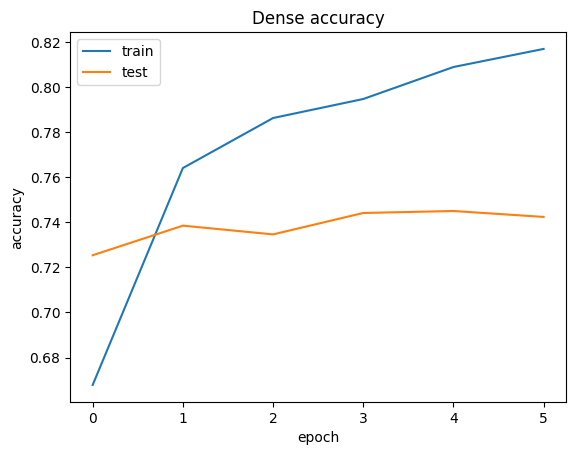

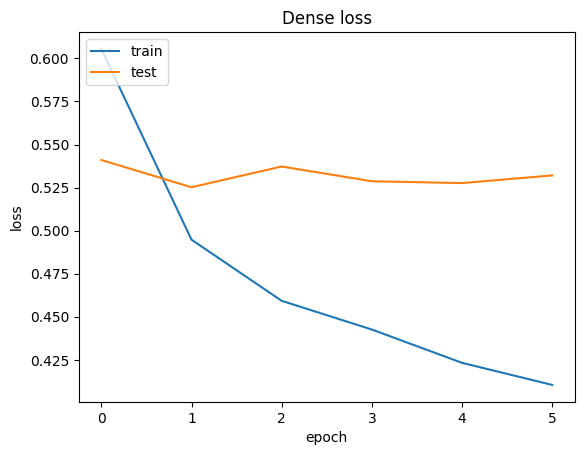

In [ ]:
def plot_history(history, title_prefix):
    acc_key = 'accuracy' if 'accuracy' in history.history else 'acc'
    val_acc_key = 'val_accuracy' if 'val_accuracy' in history.history else 'val_acc'

    plt.plot(history.history[acc_key])
    plt.plot(history.history[val_acc_key])
    plt.title(f'{title_prefix} accuracy')
    plt.ylabel('accuracy')
    plt.xlabel('epoch')
    plt.legend(['train', 'test'], loc='upper left')
    plt.show()

    plt.plot(history.history['loss'])
    plt.plot(history.history['val_loss'])
    plt.title(f'{title_prefix} loss')
    plt.ylabel('loss')
    plt.xlabel('epoch')
    plt.legend(['train', 'test'], loc='upper left')
    plt.show()

plot_history(history_dense, "Dense")

## B. Classification avec un reseau convolutionnel (CNN)
1. Creer le modele (Embedding -> Conv1D -> MaxPooling1D -> Dense sigmoid) et entrainer (epochs=6, batch_size=128, validation_split=0.2).
2. Evaluer le modele.
3. Tracer les courbes accuracy et loss (train/val) et commenter.



*   Couche Embedding : Même rôle qu'avant
*   Couche Conv1D(128, 5) : Applique 128 filtres sur des fenêtres de 5 mots → détecte des patterns locaux (ex: "not good", "very bad")
*   Couche GlobalMaxPooling1D : Garde uniquement la valeur maximale de chaque filtre → résume l'information importante
*   Couche Dense(1, sigmoid) : Sortie binaire



Epoch 1/6
250/250 ━━━━━━━━━━━━━━━━━━━━ 18s 63ms/step - accuracy: 0.7128 - loss: 0.5521 - val_accuracy: 0.7922 - val_loss: 0.4560
Epoch 2/6
250/250 ━━━━━━━━━━━━━━━━━━━━ 15s 60ms/step - accuracy: 0.8063 - loss: 0.4243 - val_accuracy: 0.8149 - val_loss: 0.4106
Epoch 3/6
250/250 ━━━━━━━━━━━━━━━━━━━━ 15s 58ms/step - accuracy: 0.8323 - loss: 0.3721 - val_accuracy: 0.8081 - val_loss: 0.4191
Epoch 4/6
250/250 ━━━━━━━━━━━━━━━━━━━━ 15s 60ms/step - accuracy: 0.8605 - loss: 0.3243 - val_accuracy: 0.8152 - val_loss: 0.4080
Epoch 5/6
250/250 ━━━━━━━━━━━━━━━━━━━━ 15s 58ms/step - accuracy: 0.8947 - loss: 0.2658 - val_accuracy: 0.8099 - val_loss: 0.4335
Epoch 6/6
250/250 ━━━━━━━━━━━━━━━━━━━━ 15s 62ms/step - accuracy: 0.9175 - loss: 0.2183 - val_accuracy: 0.8114 - val_loss: 0.4319
313/313 ━━━━━━━━━━━━━━━━━━━━ 5s 16ms/step - accuracy: 0.8117 - loss: 0.4418
Test Score: 0.4417772591114044
Test Accuracy: 0.8116999864578247


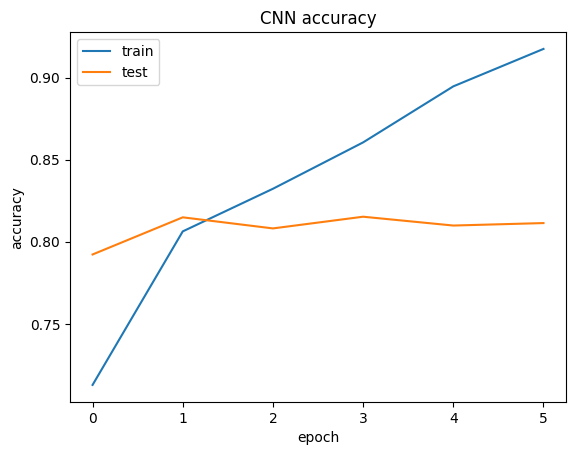

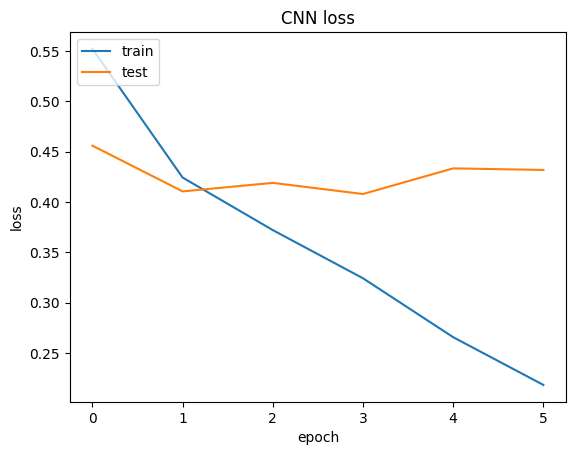

In [ ]:
model_cnn = Sequential([
    Embedding(vocab_size, 100, weights=[embedding_matrix], input_length=maxlen, trainable=False),
    Conv1D(filters=128, kernel_size=5, activation='relu'),
    MaxPooling1D(pool_size=2),
    Flatten(),
    Dense(1, activation='sigmoid')
])

model_cnn.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])
history_cnn = model_cnn.fit(
    X_train, y_train, epochs=6, batch_size=128, verbose=1, validation_split=0.2
)

score_cnn = model_cnn.evaluate(X_test, y_test, verbose=1)
print("Test Score:", score_cnn[0])
print("Test Accuracy:", score_cnn[1])

plot_history(history_cnn, "CNN")

## C. Classification avec un reseau recurrent (LSTM)
1. Creer le modele (Embedding -> LSTM -> Dense sigmoid) et entrainer (epochs=6, batch_size=128, validation_split=0.2).
2. Evaluer le modele.
3. Tracer les courbes accuracy et loss (train/val) et commenter.

Epoch 1/6
250/250 ━━━━━━━━━━━━━━━━━━━━ 82s 302ms/step - accuracy: 0.7107 - loss: 0.5595 - val_accuracy: 0.7364 - val_loss: 0.5414
Epoch 2/6
250/250 ━━━━━━━━━━━━━━━━━━━━ 74s 297ms/step - accuracy: 0.7833 - loss: 0.4569 - val_accuracy: 0.8133 - val_loss: 0.4127
Epoch 3/6
250/250 ━━━━━━━━━━━━━━━━━━━━ 85s 309ms/step - accuracy: 0.8134 - loss: 0.4056 - val_accuracy: 0.8291 - val_loss: 0.3830
Epoch 4/6
250/250 ━━━━━━━━━━━━━━━━━━━━ 82s 327ms/step - accuracy: 0.8317 - loss: 0.3748 - val_accuracy: 0.8391 - val_loss: 0.3673
Epoch 5/6
250/250 ━━━━━━━━━━━━━━━━━━━━ 75s 299ms/step - accuracy: 0.8438 - loss: 0.3560 - val_accuracy: 0.8504 - val_loss: 0.3453
Epoch 6/6
250/250 ━━━━━━━━━━━━━━━━━━━━ 43s 173ms/step - accuracy: 0.8563 - loss: 0.3282 - val_accuracy: 0.8553 - val_loss: 0.3339
313/313 ━━━━━━━━━━━━━━━━━━━━ 15s 47ms/step - accuracy: 0.8505 - loss: 0.3394
Test Score: 0.3393811881542206
Test Accuracy: 0.8504999876022339


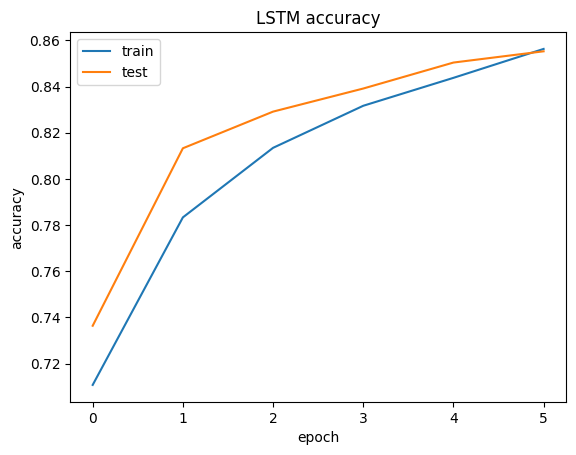

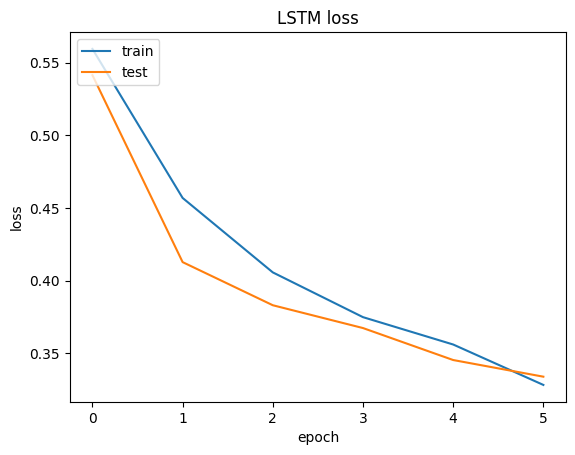

In [ ]:
model_lstm = Sequential([
    Embedding(vocab_size, 100, weights=[embedding_matrix], input_length=maxlen, trainable=False),
    LSTM(128),
    Dense(1, activation='sigmoid')
])

model_lstm.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])
history_lstm = model_lstm.fit(
    X_train, y_train, epochs=6, batch_size=128, verbose=1, validation_split=0.2
)

score_lstm = model_lstm.evaluate(X_test, y_test, verbose=1)
print("Test Score:", score_lstm[0])
print("Test Accuracy:", score_lstm[1])

plot_history(history_lstm, "LSTM")

## Comparaison et prediction
4. Comparer les resultats des 3 classifieurs.
5. Choisir une instance aleatoire et donner sa polarite.
6. Que remarquez-vous ?

In [ ]:
results = {
    "Dense": score_dense[1],
    "CNN": score_cnn[1],
    "LSTM": score_lstm[1]
}
print(results)

{'Dense': 0.739799976348877, 'CNN': 0.8116999864578247, 'LSTM': 0.8504999876022339}


In [ ]:
n_tests = 10
max_chars = 350
indices = random.sample(range(len(X_test)), n_tests)
correct = 0

for i, idx in enumerate(indices, start=1):
    sample_text = X_test_text[idx]
    true_label = "positive" if y_test[idx] == 1 else "negative"
    pred = model_lstm.predict(X_test[idx:idx+1], verbose=0)[0][0]
    pred_label = "positive" if pred >= 0.5 else "negative"
    is_ok = pred_label == true_label
    correct += int(is_ok)

    preview = (sample_text[:max_chars] + "...") if len(sample_text) > max_chars else sample_text

    print(f"--- Test {i}/{n_tests} ---")
    print("Review (prétraitée):")
    print(preview)
    print("Polarité vraie:", true_label)
    print("Polarité prédite:", pred_label, "(score=", pred, ")")
    print("Correct:", "oui" if is_ok else "non")
    print()

print(f"Exactitude sur {n_tests} tests: {correct}/{n_tests} = {correct/n_tests:.2f}")

--- Test 1/7 ---
Review (prétraitée):
The story for the first aired television installment of Columbo is simple one half of successful mystery writing team does away with the other frames an unseen Mafia group is blackmailed by an admirer does away with the admirer and is tricked up by the stalwart Columbo With that said this is still one of the most entertaining in the show history benefiting tremendously by the work of the late Jack Cassidy and star Peter Falk Besides the notability of being directed by young Steven Spielberg the episode also has air of the macabre because of the future of two of its stars Cassidy and Barbara Colby The two share several scenes together and it is poignant that both would die tragically within decade of this filming Cassidy in an apartment fire and Colby at the hands of assailants yet to be found after over three decades Now both demises are true life MYSTERIES 
Polarité vraie: positive
Polarité prédite: positive (score= 0.9726147 )

--- Test 2/7 ---
R

**Modèle Dense** : **Problème** : En aplatissant tout, le modèle perd complètement l'ordre des mots. "not good" et "good not" donnent le même vecteur ! C'est pour ça que la performance est la plus faible.


**CNN Pourquoi meilleur que Dense ?** Il comprend le contexte local (groupes de mots voisins), pas seulement les mots individuels.

**Dense** :
Le LSTM (Long Short-Term Memory) lit la review mot par mot.

## D. Compte rendu
1. Remplir le tableau des accuracies (test set) pour GloVe, Word2vec, FastText et TF-IDF.
2. Decrire les choix et interpreter les resultats.

Les cellules suivantes ajoutent GRU et RNN+CNN ainsi que Word2vec/FastText/TF-IDF.

##GRU + Glove

**GloVe : Différence avec Word2Vec :**

Sur des milliards de textes Wikipedia :
"glace" et "froid" apparaissent ensemble : 15 000 fois

"glace" et "chaud" apparaissent ensemble : 200 fois

"glace" et "soleil" apparaissent ensemble : 50 fois

→ GloVe encode ces statistiques dans des vecteurs


Pourquoi GRU ? C'est une version simplifiée du LSTM — moins de paramètres, plus rapide, souvent résultats similaires.

In [ ]:
model_gru = Sequential([
    Embedding(vocab_size, 100, weights=[embedding_matrix], input_length=maxlen, trainable=False),
    GRU(128),
    Dense(1, activation='sigmoid')
])

model_gru.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])
history_gru = model_gru.fit(
    X_train, y_train, epochs=6, batch_size=128, verbose=1, validation_split=0.2
)

score_gru = model_gru.evaluate(X_test, y_test, verbose=1)
print("GRU Test Accuracy:", score_gru[1])

Epoch 1/6
250/250 ━━━━━━━━━━━━━━━━━━━━ 78s 286ms/step - accuracy: 0.7178 - loss: 0.5306 - val_accuracy: 0.8123 - val_loss: 0.4034
Epoch 2/6
250/250 ━━━━━━━━━━━━━━━━━━━━ 75s 259ms/step - accuracy: 0.8216 - loss: 0.3923 - val_accuracy: 0.8397 - val_loss: 0.3610
Epoch 3/6
250/250 ━━━━━━━━━━━━━━━━━━━━ 70s 212ms/step - accuracy: 0.8360 - loss: 0.3645 - val_accuracy: 0.8499 - val_loss: 0.3460
Epoch 4/6
250/250 ━━━━━━━━━━━━━━━━━━━━ 34s 135ms/step - accuracy: 0.8501 - loss: 0.3403 - val_accuracy: 0.8534 - val_loss: 0.3314
Epoch 5/6
250/250 ━━━━━━━━━━━━━━━━━━━━ 19s 77ms/step - accuracy: 0.8590 - loss: 0.3215 - val_accuracy: 0.8536 - val_loss: 0.3267
Epoch 6/6
250/250 ━━━━━━━━━━━━━━━━━━━━ 29s 116ms/step - accuracy: 0.8714 - loss: 0.2994 - val_accuracy: 0.8556 - val_loss: 0.3229
313/313 ━━━━━━━━━━━━━━━━━━━━ 11s 35ms/step - accuracy: 0.8590 - loss: 0.3183
GRU Test Accuracy: 0.859000027179718


In [ ]:
model_cnn_rnn = Sequential([
    Embedding(vocab_size, 100, weights=[embedding_matrix], input_length=maxlen, trainable=False),
    Conv1D(filters=128, kernel_size=5, activation='relu'),
    MaxPooling1D(pool_size=2),
    LSTM(128),
    Dense(1, activation='sigmoid')
])

model_cnn_rnn.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])
history_cnn_rnn = model_cnn_rnn.fit(
    X_train, y_train, epochs=6, batch_size=128, verbose=1, validation_split=0.2
)

score_cnn_rnn = model_cnn_rnn.evaluate(X_test, y_test, verbose=1)
print("RNN+CNN Test Accuracy:", score_cnn_rnn[1])

Epoch 1/6
250/250 ━━━━━━━━━━━━━━━━━━━━ 59s 212ms/step - accuracy: 0.7322 - loss: 0.5223 - val_accuracy: 0.8073 - val_loss: 0.4294
Epoch 2/6
250/250 ━━━━━━━━━━━━━━━━━━━━ 24s 95ms/step - accuracy: 0.8142 - loss: 0.4062 - val_accuracy: 0.8221 - val_loss: 0.3834
Epoch 3/6
250/250 ━━━━━━━━━━━━━━━━━━━━ 16s 65ms/step - accuracy: 0.8434 - loss: 0.3559 - val_accuracy: 0.8319 - val_loss: 0.3802
Epoch 4/6
250/250 ━━━━━━━━━━━━━━━━━━━━ 16s 64ms/step - accuracy: 0.8661 - loss: 0.3178 - val_accuracy: 0.8241 - val_loss: 0.3984
Epoch 5/6
250/250 ━━━━━━━━━━━━━━━━━━━━ 27s 108ms/step - accuracy: 0.8800 - loss: 0.2844 - val_accuracy: 0.8324 - val_loss: 0.3866
Epoch 6/6
250/250 ━━━━━━━━━━━━━━━━━━━━ 37s 89ms/step - accuracy: 0.8992 - loss: 0.2457 - val_accuracy: 0.8491 - val_loss: 0.3605
313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - accuracy: 0.8454 - loss: 0.3639
RNN+CNN Test Accuracy: 0.8453999757766724


### Word2vec & FastText (entrainés sur IMDB)
Ces modèles sont entrainés sur le corpus IMDB puis utilisés comme matrices d'embedding. L'execution peut etre longue.

**Word2Vec** : Un mot est défini par les mots qui l'entourent.

Phrase : "Le roi porte une couronne"
         ↑
Word2Vec apprend que "roi" apparaît souvent
près de "couronne", "château", "reine"
→ ces mots auront des vecteurs proches.

**Limite** : Si un mot n'est pas dans le vocabulaire d'entraînement (mot inconnu) → pas de vecteur du tout.


**FastText** : Au lieu de traiter chaque mot comme une unité, FastText décompose chaque mot en morceaux de lettres (n-grammes).

**Exemple** :
Le mot "playing" est décomposé en :
"pla", "lay", "ayi", "yin", "ing", "play", "layi", "aying"...

Le vecteur de "playing" = somme des vecteurs de tous ces morceaux.

**Pourquoi c'est utile ?**

Mot inconnu : "unbelievably"
Word2Vec/GloVe →  aucun vecteur

FastText       →  "believe" + "able" + "ly" → vecteur approximatif



In [ ]:
!pip -q install gensim


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [ ]:
from gensim.models import Word2Vec, FastText

In [ ]:
tokenized_train = [s.split() for s in X_train_text]

w2v_model = Word2Vec(
    sentences=tokenized_train,
    vector_size=100,
    window=5,
    min_count=2,
    workers=4,
    epochs=5,
)

ft_model = FastText(
    sentences=tokenized_train,
    vector_size=100,
    window=5,
    min_count=2,
    workers=4,
    epochs=5,
)

In [ ]:
def build_embedding_matrix_from_gensim(wv, tokenizer, vocab_size, dim=100):
    matrix = zeros((vocab_size, dim))
    for word, index in tokenizer.word_index.items():
        if word in wv:
            matrix[index] = wv[word]
    return matrix

def train_seq_models(embedding_matrix):
    results = {}

    model_lstm_local = Sequential([
        Embedding(vocab_size, 100, weights=[embedding_matrix], input_length=maxlen, trainable=False),
        LSTM(128),
        Dense(1, activation='sigmoid')
    ])
    model_lstm_local.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])
    model_lstm_local.fit(X_train, y_train, epochs=6, batch_size=128, verbose=1, validation_split=0.2)
    results['LSTM'] = model_lstm_local.evaluate(X_test, y_test, verbose=1)[1]

    model_gru_local = Sequential([
        Embedding(vocab_size, 100, weights=[embedding_matrix], input_length=maxlen, trainable=False),
        GRU(128),
        Dense(1, activation='sigmoid')
    ])
    model_gru_local.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])
    model_gru_local.fit(X_train, y_train, epochs=6, batch_size=128, verbose=1, validation_split=0.2)
    results['GRU'] = model_gru_local.evaluate(X_test, y_test, verbose=1)[1]

    model_cnn_rnn_local = Sequential([
        Embedding(vocab_size, 100, weights=[embedding_matrix], input_length=maxlen, trainable=False),
        Conv1D(filters=128, kernel_size=5, activation='relu'),
        MaxPooling1D(pool_size=2),
        LSTM(128),
        Dense(1, activation='sigmoid')
    ])
    model_cnn_rnn_local.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])
    model_cnn_rnn_local.fit(X_train, y_train, epochs=6, batch_size=128, verbose=1, validation_split=0.2)
    results['RNN+CNN'] = model_cnn_rnn_local.evaluate(X_test, y_test, verbose=1)[1]

    return results

In [ ]:
w2v_matrix = build_embedding_matrix_from_gensim(w2v_model.wv, tokenizer, vocab_size, dim=100)
ft_matrix = build_embedding_matrix_from_gensim(ft_model.wv, tokenizer, vocab_size, dim=100)

w2v_scores = train_seq_models(w2v_matrix)
ft_scores = train_seq_models(ft_matrix)

Epoch 1/6
250/250 ━━━━━━━━━━━━━━━━━━━━ 78s 296ms/step - accuracy: 0.7863 - loss: 0.4509 - val_accuracy: 0.8270 - val_loss: 0.3871
Epoch 2/6
250/250 ━━━━━━━━━━━━━━━━━━━━ 63s 218ms/step - accuracy: 0.8450 - loss: 0.3545 - val_accuracy: 0.8537 - val_loss: 0.3381
Epoch 3/6
250/250 ━━━━━━━━━━━━━━━━━━━━ 94s 266ms/step - accuracy: 0.8658 - loss: 0.3147 - val_accuracy: 0.8550 - val_loss: 0.3291
Epoch 4/6
250/250 ━━━━━━━━━━━━━━━━━━━━ 67s 205ms/step - accuracy: 0.8820 - loss: 0.2818 - val_accuracy: 0.8626 - val_loss: 0.3155
Epoch 5/6
250/250 ━━━━━━━━━━━━━━━━━━━━ 59s 238ms/step - accuracy: 0.8982 - loss: 0.2508 - val_accuracy: 0.8605 - val_loss: 0.3284
Epoch 6/6
250/250 ━━━━━━━━━━━━━━━━━━━━ 36s 142ms/step - accuracy: 0.9127 - loss: 0.2179 - val_accuracy: 0.8635 - val_loss: 0.3266
313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 14ms/step - accuracy: 0.8596 - loss: 0.3279
Epoch 1/6
250/250 ━━━━━━━━━━━━━━━━━━━━ 21s 77ms/step - accuracy: 0.7516 - loss: 0.4930 - val_accuracy: 0.8405 - val_loss: 0.3667
Epoch 2/6
250/2

### TF-IDF (classifieur MLP/LogReg)
TF-IDF est une representation non sequencee, donc on utilise un classifieur lineaire pour cette colonne.

**TF-IDF** :  Représenter chaque document par un vecteur qui indique l'importance de chaque mot.

TF  = nombre de fois que le mot apparaît dans CE document
IDF = log(nombre total de documents / documents contenant ce mot)

TF-IDF = TF × IDF

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression

tfidf = TfidfVectorizer(max_features=20000)
X_train_tfidf = tfidf.fit_transform(X_train_text)
X_test_tfidf = tfidf.transform(X_test_text)

tfidf_clf = LogisticRegression(max_iter=1000)
tfidf_clf.fit(X_train_tfidf, y_train)
tfidf_acc = tfidf_clf.score(X_test_tfidf, y_test)
tfidf_acc

0.9005

In [ ]:
report_table = pd.DataFrame(
    {
        "GloVe": [score_lstm[1], score_gru[1], score_cnn_rnn[1]],
        "Word2vec": [w2v_scores['LSTM'], w2v_scores['GRU'], w2v_scores['RNN+CNN']],
        "Fasttext": [ft_scores['LSTM'], ft_scores['GRU'], ft_scores['RNN+CNN']],
        "Tf-idf": [tfidf_acc, tfidf_acc, tfidf_acc],
    },
    index=["LSTM", "GRU", "RNN+CNN"],
)

report_table

,GloVe,Word2vec,Fasttext,Tf-idf
LSTM,0.8505,0.8596,0.8486,0.9005
GRU,0.8590,0.8738,0.8626,0.9005
RNN+CNN,0.8454,0.8458,0.8388,0.9005


### Interprétation
Sur le tableau final, **TF-IDF + Logistic Regression** obtient la meilleure accuracy (0.9005). Cela montre que, pour IMDB, une representation sac-de-mots bien calibree peut surpasser les modeles sequencee profonds dans ce setup.
Pour les embeddings distribues, **Word2vec** donne les meilleurs resultats parmi les embeddings appris (GRU 0.8738, LSTM 0.8596), suivi de **FastText** (GRU 0.8626) puis **GloVe** (GRU 0.8590). Le **GRU** reste globalement le meilleur classifieur sequence, ce qui confirme son bon compromis entre capacite et regularisation. **RNN+CNN** reste en retrait, probablement a cause d'une complexite superieure et d'une optimisation plus delicate avec 6 epochs.